In [2]:
# Import the pandas library which allows us to load, inspect and manipulate dataframes
import pandas as pd

# Technical parameter - ignore :)
%matplotlib inline

<h1><center>1. LOAD THE DATA</center></h1>


In [3]:
# Load the data into a dataframe
df = pd.read_csv('data_unclean.csv', sep=';')
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,client_since,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,0,5,may,261,1,-1,0,unknown,no
1,44.0,technician,single,secondary,no,29,yes,no,unknown,0,5,may,151,1,-1,0,unknown,no
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,0,5,may,76,1,-1,0,unknown,no
3,47.0,blue-collar,married,unknown,no,1506,yes,no,unknown,0,5,may,92,1,-1,0,unknown,no
4,33.0,unknown,single,unknown,no,1,no,no,unknown,0,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,technician,married,tertiary,no,825,no,no,cellular,0,17,nov,977,3,-1,0,unknown,yes
45207,71.0,retired,divorced,primary,no,1729,no,no,cellular,0,17,nov,456,2,-1,0,unknown,yes
45208,72.0,retired,married,secondary,no,5715,no,no,cellular,0,17,nov,1127,5,184,3,success,yes
45209,57.0,blue-collar,married,secondary,no,668,no,no,telephone,0,17,nov,508,4,-1,0,unknown,no


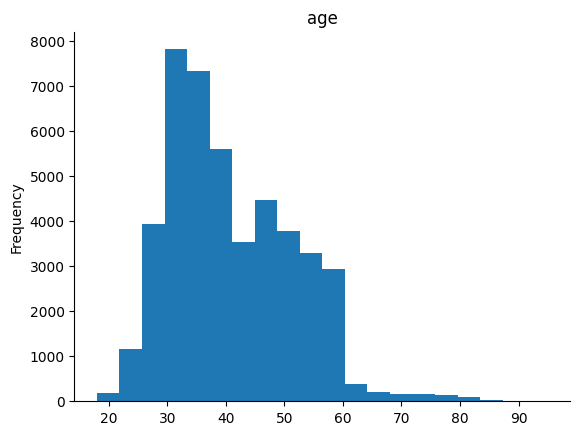

In [3]:
# @title age

from matplotlib import pyplot as plt
df['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

<h1><center>2. INSPECT THE DATA</center></h1>

In [4]:
# Let's look at the shape of our data - how many entries and columns are there?
print("Number of rows: ", len(df))
print("Number of columns: ", len(df.columns))

Number of rows:  45211
Number of columns:  18


In [5]:
# Quicker way:
df.shape

(45211, 18)

<h1><center>3. DEALING WITH EMPTY VALUES ("Null-Values")</center></h1>

In [6]:
# First thing to notice: are there any missing values?
df.isnull().sum()
# Uh oh, looks like we have some missing values in the age column

age             15
job              0
marital          0
education        0
default          0
balance          0
housing          0
loan             0
contact          0
client_since     0
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome         0
y                0
dtype: int64

In [7]:
# Quicker way:
df.info()
# Note that we have 45211 rows (see second line), but for age, there are only 45196 non-null values => 15 values are empty (see 6th line)

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           45196 non-null  float64
 1   job           45211 non-null  str    
 2   marital       45211 non-null  str    
 3   education     45211 non-null  str    
 4   default       45211 non-null  str    
 5   balance       45211 non-null  int64  
 6   housing       45211 non-null  str    
 7   loan          45211 non-null  str    
 8   contact       45211 non-null  str    
 9   client_since  45211 non-null  int64  
 10  day           45211 non-null  int64  
 11  month         45211 non-null  str    
 12  duration      45211 non-null  int64  
 13  campaign      45211 non-null  int64  
 14  pdays         45211 non-null  int64  
 15  previous      45211 non-null  int64  
 16  poutcome      45211 non-null  str    
 17  y             45211 non-null  str    
dtypes: float64(1), int64(7), str(10)
memo

## Typically, here are a few ways to deal with missing data:

1.   List item
2.   List item



In [8]:
# First option:
df_example1 = df.dropna()
df_example1.info()
# We dropped the 15 rows where age was empty. We now only have 45196 rows in total, but none of them contain any missing values.

<class 'pandas.core.frame.DataFrame'>
Index: 45196 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           45196 non-null  float64
 1   job           45196 non-null  object 
 2   marital       45196 non-null  object 
 3   education     45196 non-null  object 
 4   default       45196 non-null  object 
 5   balance       45196 non-null  int64  
 6   housing       45196 non-null  object 
 7   loan          45196 non-null  object 
 8   contact       45196 non-null  object 
 9   client_since  45196 non-null  int64  
 10  day           45196 non-null  int64  
 11  month         45196 non-null  object 
 12  duration      45196 non-null  int64  
 13  campaign      45196 non-null  int64  
 14  pdays         45196 non-null  int64  
 15  previous      45196 non-null  int64  
 16  poutcome      45196 non-null  object 
 17  y             45196 non-null  object 
dtypes: float64(1), int64(7), object

In [8]:
# Second option
df_example1 = df.dropna(axis=1)
df_example1.info()
# We kept the 15 rows where age was empty and deleted the whole age column instead. We now still have 45211 rows in total, but only 17 columns (see 3rd line).

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   job           45211 non-null  str  
 1   marital       45211 non-null  str  
 2   education     45211 non-null  str  
 3   default       45211 non-null  str  
 4   balance       45211 non-null  int64
 5   housing       45211 non-null  str  
 6   loan          45211 non-null  str  
 7   contact       45211 non-null  str  
 8   client_since  45211 non-null  int64
 9   day           45211 non-null  int64
 10  month         45211 non-null  str  
 11  duration      45211 non-null  int64
 12  campaign      45211 non-null  int64
 13  pdays         45211 non-null  int64
 14  previous      45211 non-null  int64
 15  poutcome      45211 non-null  str  
 16  y             45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [9]:
# Third option (more complex):
# Impute data, e.g. with the average age - where do you think this is useful?

## In the real world, don't rely on the info() function too much!

In [10]:
# The client_since column seems to contain a weirdly high amount of 0s. Let's look into the values there for the first 10 rows:
df['client_since'].head(100)

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    0
97    0
98    0
99    0
Name: client_since, Length: 100, dtype: int64

In [18]:
# In fact, the column contains only one value: 0
# This is obviously an error, as having a zero there makes no sense at all
df['age'].astype(int)

ValueError: cannot convert NA to integer

In [12]:
# Since the column only contains one unique value and thus does not provide any helpful information, we should delete it:
df_clean = df.drop(columns=['client_since'])
display(df_clean)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47.0,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33.0,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71.0,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72.0,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57.0,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45196 non-null  float64
 1   job        45211 non-null  str    
 2   marital    45211 non-null  str    
 3   education  45211 non-null  str    
 4   default    45211 non-null  str    
 5   balance    45211 non-null  int64  
 6   housing    45211 non-null  str    
 7   loan       45211 non-null  str    
 8   contact    45211 non-null  str    
 9   day        45211 non-null  int64  
 10  month      45211 non-null  str    
 11  duration   45211 non-null  int64  
 12  campaign   45211 non-null  int64  
 13  pdays      45211 non-null  int64  
 14  previous   45211 non-null  int64  
 15  poutcome   45211 non-null  str    
 16  y          45211 non-null  str    
dtypes: float64(1), int64(6), str(10)
memory usage: 5.9 MB
